Raw neural shape: (432017, 129)
Raw syllables shape: (432017,)
Train timepoints: 324012
Test timepoints: 108005
PC data shape: (432017, 10)
Explained variance ratio: [0.0734137  0.04252737 0.03691512 0.03305066 0.03035523 0.02670374
 0.02320464 0.02032289 0.01833607 0.01749001]
Cumulative explained variance: [0.0734137  0.11594106 0.15285619 0.18590684 0.21626207 0.24296582
 0.26617044 0.28649333 0.3048294  0.3223194 ]
Train transitions: 324012
Test transitions: 108004
Using device: cuda
Epoch 000 | Train loss: 4.175027 | Test TF loss: 3.201237
Epoch 020 | Train loss: 3.955537 | Test TF loss: 2.999978
Epoch 040 | Train loss: 2.899591 | Test TF loss: 2.161644
Epoch 060 | Train loss: 2.090351 | Test TF loss: 1.548423
Epoch 080 | Train loss: 1.624746 | Test TF loss: 1.245527
Epoch 100 | Train loss: 1.290473 | Test TF loss: 0.978579
Epoch 120 | Train loss: 0.917243 | Test TF loss: 0.675741
Epoch 140 | Train loss: 0.623177 | Test TF loss: 0.497614
Epoch 160 | Train loss: 0.487700 | Test TF 

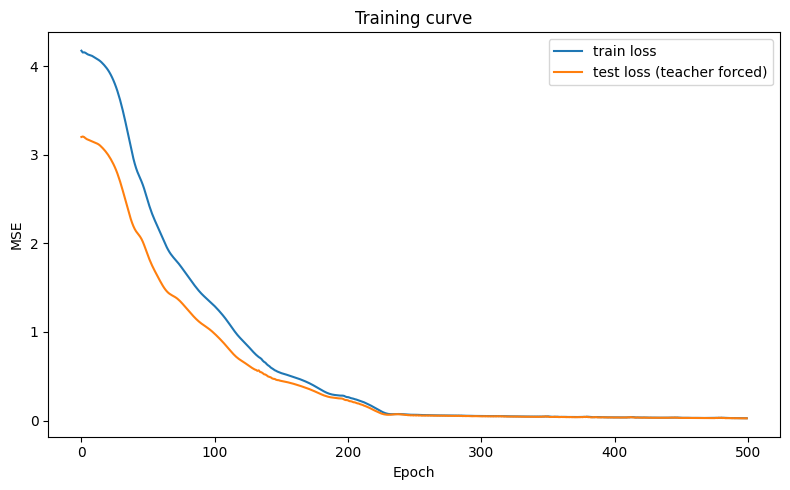

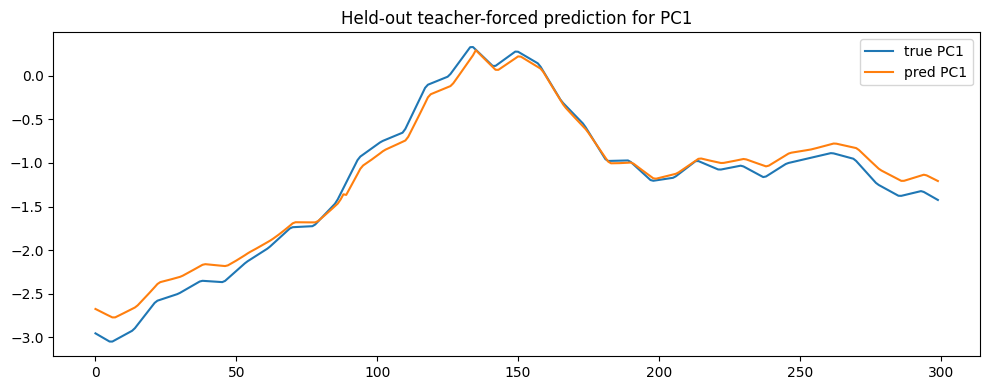

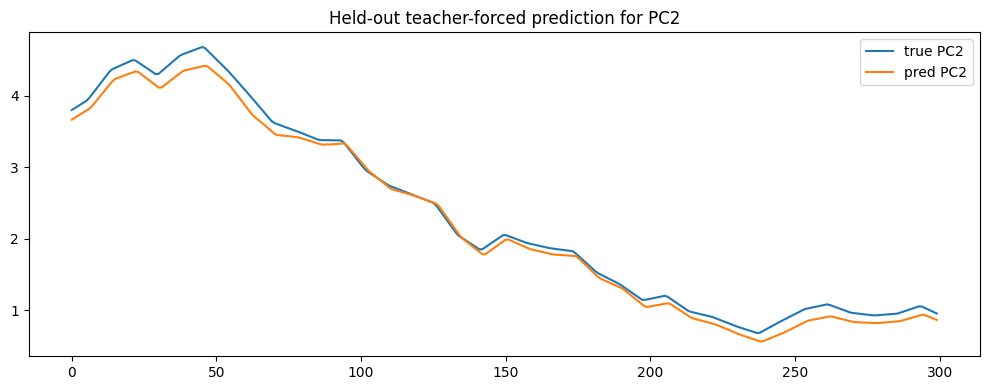

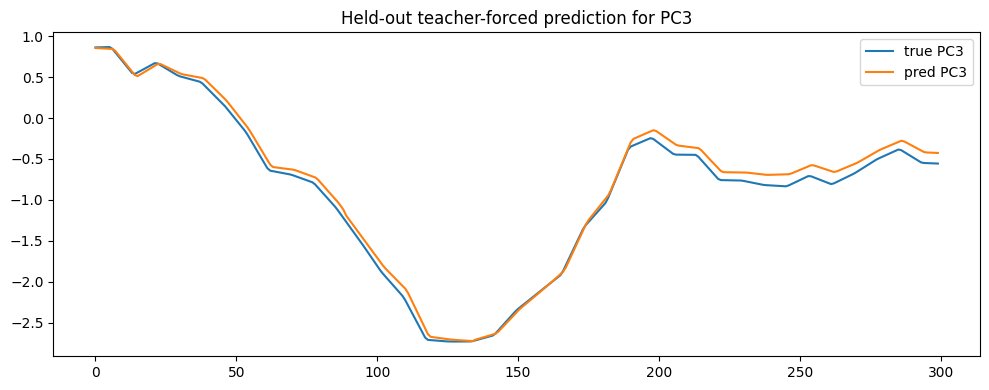

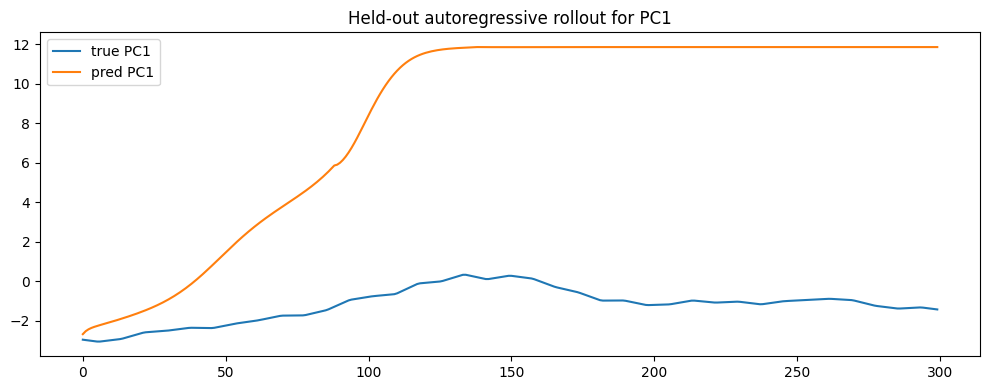

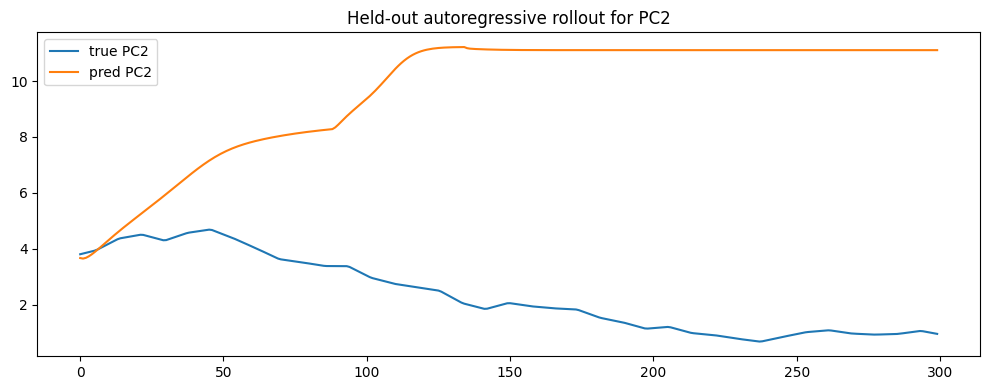

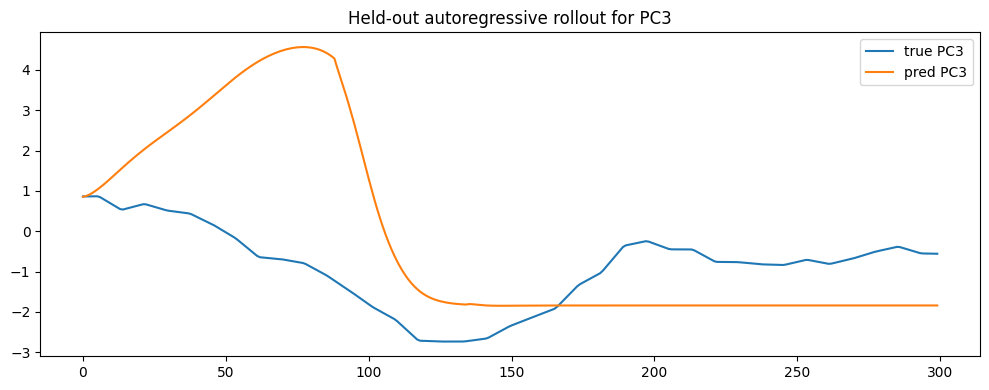

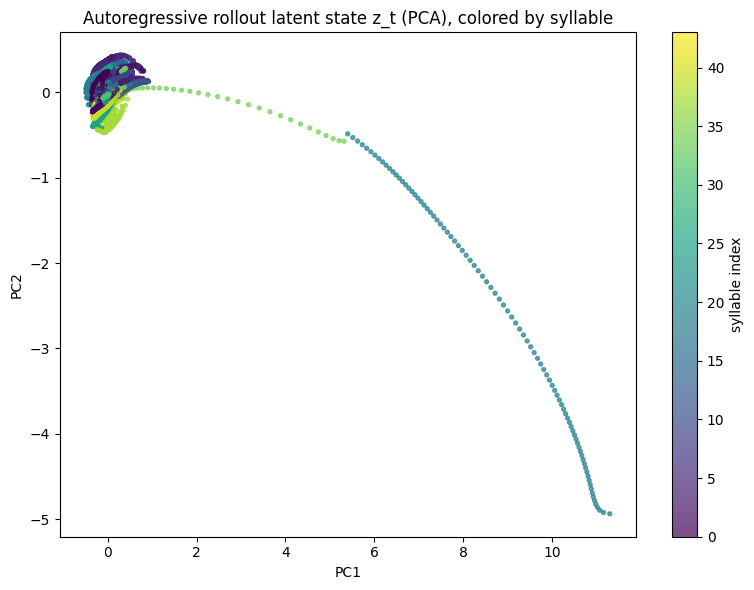

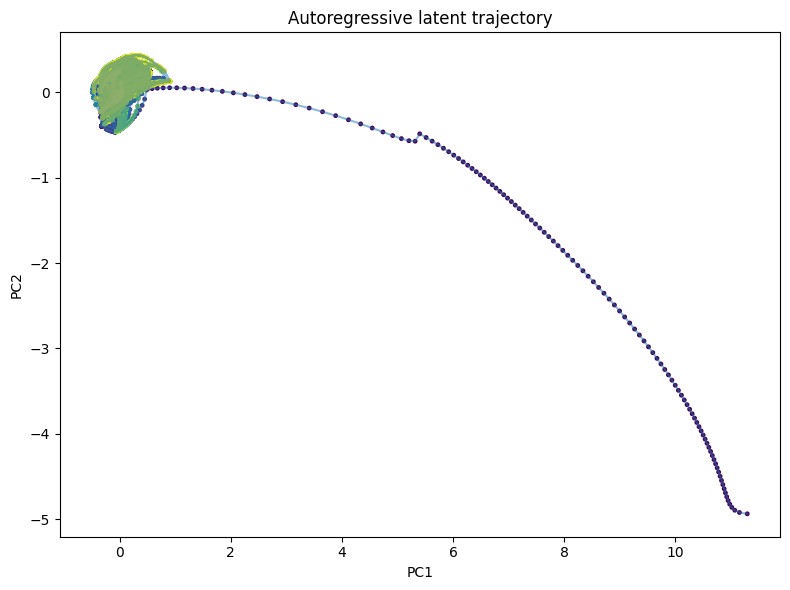

Done.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


class SyllablePCModel(nn.Module):
    def __init__(self, n_pcs, n_syllables, emb_dim=16, hidden_dim=128):
        super().__init__()

        self.syll_embedding = nn.Embedding(n_syllables, emb_dim)

        self.pc_encoder = nn.Sequential(
            nn.Linear(n_pcs, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + emb_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.predict_next_pc = nn.Linear(hidden_dim, n_pcs)

    def forward(self, x_t, syll_t):
        e_t = self.syll_embedding(syll_t)
        h_t = self.pc_encoder(x_t)
        z_t = self.fusion(torch.cat([h_t, e_t], dim=-1))
        x_next_pred = self.predict_next_pc(z_t)
        return x_next_pred, z_t, e_t


def make_transition_split(neural_pcs, syllables_idx, train_frac=0.75):
    x_t = neural_pcs[:-1].astype(np.float32)
    x_tp1 = neural_pcs[1:].astype(np.float32)
    syll_t = syllables_idx[:-1].astype(np.int64)

    n_transitions = len(x_t)
    split_idx = int(train_frac * n_transitions)

    return {
        "train": {
            "x_t": x_t[:split_idx],
            "syll_t": syll_t[:split_idx],
            "x_tp1": x_tp1[:split_idx],
        },
        "test": {
            "x_t": x_t[split_idx:],
            "syll_t": syll_t[split_idx:],
            "x_tp1": x_tp1[split_idx:],
        },
        "split_idx": split_idx,
    }


def to_torch(split_dict, device):
    return {
        "x_t": torch.tensor(split_dict["x_t"], dtype=torch.float32, device=device),
        "syll_t": torch.tensor(split_dict["syll_t"], dtype=torch.long, device=device),
        "x_tp1": torch.tensor(split_dict["x_tp1"], dtype=torch.float32, device=device),
    }


def evaluate_teacher_forced(model, x_t, syll_t, x_tp1, loss_fn):
    model.eval()
    with torch.no_grad():
        pred, z_t, e_t = model(x_t, syll_t)
        loss = loss_fn(pred, x_tp1).item()
    return {
        "loss": loss,
        "pred": pred.cpu().numpy(),
        "true": x_tp1.cpu().numpy(),
        "z": z_t.cpu().numpy(),
        "e": e_t.cpu().numpy(),
    }


def rollout_autoregressive(model, x0, syll_seq, true_future, device="cpu"):
    """
    Free-running rollout on test set.

    x0:         shape [n_pcs]          initial true neural PC state
    syll_seq:   shape [T_rollout]      syllables for each step t
    true_future shape [T_rollout, n_pcs]
               ground-truth x_{t+1}, x_{t+2}, ... aligned to predictions

    At step k:
      input  = current predicted state x_hat_t and true syllable s_t
      output = predicted next state x_hat_{t+1}

    Returns predictions for the whole rollout horizon.
    """
    model.eval()

    preds = []
    latents = []
    embeds = []

    x_curr = torch.tensor(x0, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for s in syll_seq:
            s_t = torch.tensor([s], dtype=torch.long, device=device)
            x_next_pred, z_t, e_t = model(x_curr, s_t)

            preds.append(x_next_pred.squeeze(0).cpu().numpy())
            latents.append(z_t.squeeze(0).cpu().numpy())
            embeds.append(e_t.squeeze(0).cpu().numpy())

            # free-running: feed prediction back in
            x_curr = x_next_pred

    preds = np.stack(preds, axis=0)
    latents = np.stack(latents, axis=0)
    embeds = np.stack(embeds, axis=0)

    mse = np.mean((preds - true_future) ** 2)

    return {
        "pred": preds,
        "true": true_future,
        "z": latents,
        "e": embeds,
        "loss": mse,
    }


def persistence_rollout_baseline(x0, horizon, true_future):
    """
    Baseline: keep predicting the last state forever.
    """
    pred = np.repeat(x0[None, :], horizon, axis=0)
    mse = np.mean((pred - true_future) ** 2)
    return {
        "pred": pred,
        "true": true_future,
        "loss": mse,
    }


def plot_predictions(true, pred, title_prefix="Test", max_points=300, n_plot_pcs=3):
    n_pcs = true.shape[1]
    n_plot_pcs = min(n_plot_pcs, n_pcs)
    n_show = min(max_points, len(true))

    for pc_idx in range(n_plot_pcs):
        plt.figure(figsize=(10, 4))
        plt.plot(true[:n_show, pc_idx], label=f"true PC{pc_idx + 1}")
        plt.plot(pred[:n_show, pc_idx], label=f"pred PC{pc_idx + 1}")
        plt.title(f"{title_prefix} for PC{pc_idx + 1}")
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_loss_curves(train_losses, test_tf_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="train loss")
    plt.plot(test_tf_losses, label="test loss (teacher forced)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_rollout_latent(z_np, syll_t_np):
    z_2d = PCA(n_components=2).fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np,
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title("Autoregressive rollout latent state z_t (PCA), colored by syllable")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.5)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title("Autoregressive latent trajectory")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def main():
    # -------------------------
    # Load data
    # -------------------------
    neural = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/object_interaction_neural_rec.npy')
    syllables = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/object_interaction_moseq_syllables_aux.npy')

    print("Raw neural shape:", neural.shape)
    print("Raw syllables shape:", syllables.shape)

    if neural.ndim != 2:
        raise ValueError(f"Expected neural shape [T, n_neurons], got {neural.shape}")

    syllables = np.asarray(syllables).squeeze()
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables shape [T], got {syllables.shape}")

    if len(neural) != len(syllables):
        raise ValueError("neural and syllables must have same number of timepoints")

    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # -------------------------
    # Split in time before preprocessing
    # -------------------------
    T = len(neural)
    train_time_end = int(0.75 * T)

    neural_train = neural[:train_time_end]
    neural_test = neural[train_time_end:]

    print("Train timepoints:", len(neural_train))
    print("Test timepoints:", len(neural_test))

    # -------------------------
    # Fit scaler/PCA on train only
    # -------------------------
    scaler = StandardScaler()
    neural_train_scaled = scaler.fit_transform(neural_train)
    neural_test_scaled = scaler.transform(neural_test)

    n_pcs = 10
    pca = PCA(n_components=n_pcs)
    neural_train_pcs = pca.fit_transform(neural_train_scaled)
    neural_test_pcs = pca.transform(neural_test_scaled)

    neural_pcs = np.concatenate([neural_train_pcs, neural_test_pcs], axis=0)

    print("PC data shape:", neural_pcs.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

    # -------------------------
    # Build transitions
    # -------------------------
    split_data = make_transition_split(neural_pcs, syllables_idx, train_frac=0.75)

    print("Train transitions:", len(split_data["train"]["x_t"]))
    print("Test transitions:", len(split_data["test"]["x_t"]))

    # -------------------------
    # Torch
    # -------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_torch = to_torch(split_data["train"], device)
    test_torch = to_torch(split_data["test"], device)

    # -------------------------
    # Model
    # -------------------------
    model = SyllablePCModel(
        n_pcs=n_pcs,
        n_syllables=len(unique_sylls),
        emb_dim=16,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # -------------------------
    # Train
    # -------------------------
    n_epochs = 500
    train_losses = []
    test_tf_losses = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        pred_train, _, _ = model(train_torch["x_t"], train_torch["syll_t"])
        train_loss = loss_fn(pred_train, train_torch["x_tp1"])
        train_loss.backward()
        optimizer.step()

        # keep teacher-forced test only as a diagnostic during training
        model.eval()
        with torch.no_grad():
            pred_test_tf, _, _ = model(test_torch["x_t"], test_torch["syll_t"])
            test_tf_loss = loss_fn(pred_test_tf, test_torch["x_tp1"])

        train_losses.append(train_loss.item())
        test_tf_losses.append(test_tf_loss.item())

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train loss: {train_loss.item():.6f} | "
                f"Test TF loss: {test_tf_loss.item():.6f}"
            )

    # -------------------------
    # Final teacher-forced eval
    # -------------------------
    train_eval = evaluate_teacher_forced(
        model,
        train_torch["x_t"],
        train_torch["syll_t"],
        train_torch["x_tp1"],
        loss_fn,
    )

    test_eval_tf = evaluate_teacher_forced(
        model,
        test_torch["x_t"],
        test_torch["syll_t"],
        test_torch["x_tp1"],
        loss_fn,
    )

    # -------------------------
    # Autoregressive rollout on held-out 25%
    # -------------------------
    # We need an initial state x0 at the start of test transitions.
    # Then use all test syllables s_t to predict the full future sequence.
    x0_test = split_data["test"]["x_t"][0]                 # true initial held-out state
    syll_test_seq = split_data["test"]["syll_t"]           # s_t for each rollout step
    true_test_future = split_data["test"]["x_tp1"]         # true x_{t+1}

    test_eval_rollout = rollout_autoregressive(
        model=model,
        x0=x0_test,
        syll_seq=syll_test_seq,
        true_future=true_test_future,
        device=device,
    )

    # -------------------------
    # Baselines
    # -------------------------
    baseline_tf_test = np.mean(
        (split_data["test"]["x_t"] - split_data["test"]["x_tp1"]) ** 2
    )

    baseline_rollout = persistence_rollout_baseline(
        x0=x0_test,
        horizon=len(true_test_future),
        true_future=true_test_future,
    )

    # -------------------------
    # Results
    # -------------------------
    print("\nFinal results")
    print("Train MSE:", train_eval["loss"])
    print("Held-out teacher-forced test MSE:", test_eval_tf["loss"])
    print("Held-out autoregressive rollout MSE:", test_eval_rollout["loss"])
    print("Teacher-forced persistence baseline MSE:", baseline_tf_test)
    print("Autoregressive persistence baseline MSE:", baseline_rollout["loss"])

    # -------------------------
    # Plots
    # -------------------------
    plot_loss_curves(train_losses, test_tf_losses)

    plot_predictions(
        true=test_eval_tf["true"],
        pred=test_eval_tf["pred"],
        title_prefix="Held-out teacher-forced prediction",
        max_points=300,
        n_plot_pcs=3,
    )

    plot_predictions(
        true=test_eval_rollout["true"],
        pred=test_eval_rollout["pred"],
        title_prefix="Held-out autoregressive rollout",
        max_points=300,
        n_plot_pcs=3,
    )

    visualize_rollout_latent(
        z_np=test_eval_rollout["z"],
        syll_t_np=syll_test_seq,
    )

    print("Done.")
    return {
        "model": model,
        "pca": pca,
        "scaler": scaler,
        "split_data": split_data,
        "train_eval": train_eval,
        "test_eval_tf": test_eval_tf,
        "test_eval_rollout": test_eval_rollout,
        "baseline_tf_test": baseline_tf_test,
        "baseline_rollout": baseline_rollout,
    }


results = main()

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px


def visualize_rollout_latent_3d_plotly(
    z_np,
    syll_t_np=None,
    color_by="syllable",
    title="Autoregressive rollout latent state z_t (3D PCA)",
):
    """
    Interactive 3D PCA plot of rollout latent states.

    Parameters
    ----------
    z_np : np.ndarray
        Latent states of shape [T, D]
    syll_t_np : np.ndarray or None
        Syllable indices of shape [T]
    color_by : str
        "syllable" or "time"
    title : str
        Plot title
    """
    pca_3d = PCA(n_components=3)
    z_3d = pca_3d.fit_transform(z_np)

    df_plot = pd.DataFrame({
        "PC1": z_3d[:, 0],
        "PC2": z_3d[:, 1],
        "PC3": z_3d[:, 2],
        "time": np.arange(len(z_3d)),
    })

    if syll_t_np is not None:
        df_plot["syllable"] = syll_t_np[:len(z_3d)]

    if color_by == "syllable":
        if syll_t_np is None:
            raise ValueError("syll_t_np must be provided when color_by='syllable'")
        color_col = "syllable"
    elif color_by == "time":
        color_col = "time"
    else:
        raise ValueError("color_by must be either 'syllable' or 'time'")

    fig = px.line_3d(
        df_plot,
        x="PC1",
        y="PC2",
        z="PC3",
        color=color_col,
        title=title,
        hover_data=["time"] + (["syllable"] if "syllable" in df_plot.columns else []),
    )

    fig.update_traces(marker=dict(size=3))
    fig.update_layout(
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=1000,
        height=800,
    )

    print("Explained variance ratio (3D PCA):", pca_3d.explained_variance_ratio_)
    print("Cumulative explained variance (3D PCA):", np.cumsum(pca_3d.explained_variance_ratio_))

    fig.show()
    return fig, z_3d, pca_3d

fig, z_3d, pca_3d = visualize_rollout_latent_3d_plotly(
    z_np=results["test_eval_rollout"]["z"],
    syll_t_np=results["split_data"]["test"]["syll_t"],
    color_by="syllable",
    title="Object exploration rollout latent (3D PCA, colored by syllable)",
)

Explained variance ratio (3D PCA): [0.41116768 0.1633351  0.12160874]
Cumulative explained variance (3D PCA): [0.41116768 0.57450277 0.6961115 ]
